# Unit 1: The Derivative and the Difference Quotient

In Unit 0, we learned that limits allow us to see what a function approaches as our step size gets infinitesimally small. Now, we will apply that exact concept to the slope of a line.

The derivative is simply the instantaneous rate of change of a function. By the end of this notebook, you will have written an algorithm to calculate the derivative of any mathematical function.

First, let's load our essential libraries.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


## 1. From Secant to Tangent

In algebra, you learned how to find the slope between two points using the formula $m = \frac{y_2 - y_1}{x_2 - x_1}$. A line connecting two points on a curve is called a **secant line**.

Let's look at the function $f(x) = x^2$ and draw a secant line between $x=1$ and $x=3$.


Slope of the secant line: 4.0


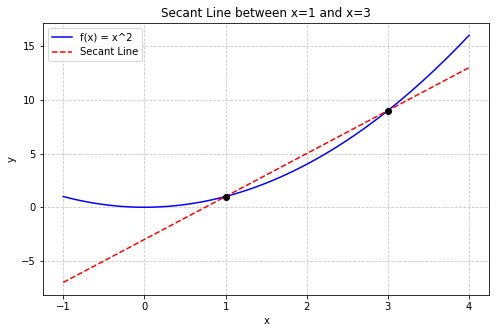

In [2]:
f = lambda x: x**2

# Our two x-values
x1 = 1.0
x2 = 3.0

# Calculate the corresponding y-values
y1 = f(x1)
y2 = f(x2)

# Calculate the slope (m)
m = (y2 - y1) / (x2 - x1)
print("Slope of the secant line:", m)

# Create the equation of the secant line: y = m*(x - x1) + y1
secant_line = lambda x: m * (x - x1) + y1

# Let's graph it!
x_vals = np.linspace(-1, 4, 100)
plt.figure(figsize=(8, 5))

plt.plot(x_vals, f(x_vals), label="f(x) = x^2", color="blue")
plt.plot(x_vals, secant_line(x_vals), label="Secant Line", color="red", linestyle="--")

# Mark our two points
plt.scatter([x1, x2], [y1, y2], color="black", zorder=5)

plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Secant Line between x=1 and x=3")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


Calculus asks a simple question: *What happens to that secant line if we slide the second point closer and closer to the first point?* When the distance between the two points approaches zero, the secant line becomes a **tangent line**, intersecting the curve at exactly one point. The slope of that tangent line is the derivative.

## 2. The Difference Quotient in Code

Instead of calling our points $x_1$ and $x_2$, let's call our first point $x$. We will define the distance between our two points as $h$. Therefore, our second point is $x + h$.

If we plug these into our algebraic slope formula, we get the formal definition of the derivative, known as the **Difference Quotient**:


$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Let's write a reusable Python function that computes this!


In [3]:
def numerical_derivative(f, x, h=1e-5):
    """
    Approximates the derivative of a function f at a given x.
    h is the step size, defaulting to a very small number.
    """
    return (f(x + h) - f(x)) / h

# Let's test it on f(x) = x^2 at x = 1
# We know algebraically from the Power Rule that the derivative should be exactly 2
approx_slope = numerical_derivative(f, x=1.0)

print("Calculated instantaneous slope at x=1:", approx_slope)


Calculated instantaneous slope at x=1: 2.00001000001393



## 3. Tuning the Step Size ($h$)

Notice that our `numerical_derivative` function returned `2.000009999995333`, not perfectly `2`. This is because we cannot actually set $h = 0$ (that would cause a `ZeroDivisionError`).

In Unit 0, we learned that making our numbers *too* small causes floating-point precision errors. Let's run a test using different values of $h$ to see this in action. We will test the derivative of $f(x) = x^2$ at $x = 1$.


In [4]:

# Create an array of shrinking h values (from 0.1 down to 10^-17)
h_values = np.array([10**(-i) for i in range(1, 18)])

# Calculate the derivative for each h
computed_slopes = numerical_derivative(f, x=1.0, h=h_values)

# We know the true mathematical answer is exactly 2.0
true_slope = 2.0
errors = np.abs(computed_slopes - true_slope)

# Put it in a table
h_table = pd.DataFrame({
    'Step Size (h)': h_values,
    'Computed Slope': computed_slopes,
    'Absolute Error': errors
})

print(h_table)


    Step Size (h)  Computed Slope  Absolute Error
0    1.000000e-01        2.100000    1.000000e-01
1    1.000000e-02        2.010000    1.000000e-02
2    1.000000e-03        2.001000    1.000000e-03
3    1.000000e-04        2.000100    1.000000e-04
4    1.000000e-05        2.000010    1.000001e-05
5    1.000000e-06        2.000001    9.999244e-07
6    1.000000e-07        2.000000    1.010878e-07
7    1.000000e-08        2.000000    1.215494e-08
8    1.000000e-09        2.000000    1.654807e-07
9    1.000000e-10        2.000000    1.654807e-07
10   1.000000e-11        2.000000    1.654807e-07
11   1.000000e-12        2.000178    1.778012e-04
12   1.000000e-13        1.998401    1.598556e-03
13   1.000000e-14        1.998401    1.598556e-03
14   1.000000e-15        2.220446    2.204460e-01
15   1.000000e-16        0.000000    2.000000e+00
16   1.000000e-17        0.000000    2.000000e+00



> **Analyze the Table:** Look at the `Absolute Error` column.
> * At the top (when $h=0.1$), the error is large because our two points are too far apart. The math is inaccurate.
> * In the middle (around $h=10^{-8}$), the error hits rock bottom. This is our "Goldilocks zone."
> * At the bottom (when $h=10^{-16}$), the error violently spikes, and the computed slope drops to `0.0`. The computer has completely lost track of the floating-point decimals.
> 
> 

When performing numerical calculus in Python, selecting the correct step size is just as important as knowing the math.

## 4. Graphing the Derivative

The true power of computing is doing thousands of calculations in a fraction of a second. Instead of finding the derivative at a single point, let's find the derivative for an entire array of points and plot it.


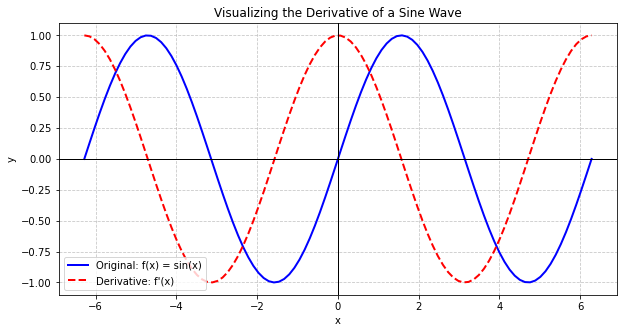

In [5]:
# A new function: f(x) = sin(x)
f_sin = lambda x: np.sin(x)

# An array of x-values
x_domain = np.linspace(-2*np.pi, 2*np.pi, 100)

# Calculate the derivative array
# Because we used numpy for our functions, our numerical_derivative handles arrays natively!
y_prime = numerical_derivative(f_sin, x_domain, h=1e-5)

plt.figure(figsize=(10, 5))

# Plot the original function
plt.plot(x_domain, f_sin(x_domain), label="Original: f(x) = sin(x)", color="blue", linewidth=2)

# Plot the derivative
plt.plot(x_domain, y_prime, label="Derivative: f'(x)", color="red", linestyle="--", linewidth=2)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Visualizing the Derivative of a Sine Wave")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
